In [ ]:
# Globals
import numpy as np

from shared_util.pipelines import ModelPipeline
import warnings
warnings.filterwarnings('ignore')

METRICS_DB_ID = 9
METRICS_NOTES = "adaptive one-hot"
PCA = False
scaler = 'standard' # 'standard' for StandardScaler or 'power' for PowerTransformer (yeo-johnson)



UPDATE_DATABASE = True

LOG_TRANSFORM_COLS = np.array(
    ['num_medications', 'num_procedures', 'time_in_hospital', 'number_inpatient'
     ])

# Results

In [16]:
from shared_util.fetch import fetch_metric, fetch_all_metrics
import pandas as pd
from shared_util.pd_util import filter_df

metrics_df = filter_df(fetch_all_metrics(), run_id=[1,2,3,4,5,6,7,8,9,10,11,12,13])

pca_ = filter_df(metrics_df, run_id=2)
log_scale_ = filter_df(metrics_df, run_id=1)
pt_ = filter_df(metrics_df, run_id=3)
pt_log = filter_df(metrics_df, run_id=4)
bin_v2 = filter_df(metrics_df, run_id=5)
bin_v3 = filter_df(metrics_df, run_id=6)

# pca_results_df = fetch_metric(run_id=2)
# results_df = fetch_metric(run_id=1)

# pt_df = fetch_metric(run_id=3)

# pt_log_df = fetch_metric(run_id=4)

# new_bin = fetch_metric(run_id=5)

# bin_3 = fetch_metric(run_id=6)



test_df = filter_df(metrics_df, data=['test'])


most_recent_df = filter_df(metrics_df, run_id=[METRICS_DB_ID])


filter_df(most_recent_df, data='test').head(5)

,id,run_id,model,data,threshold_notes,pipeline_notes,hyperparam_notes,notes,roc_auc,accuracy,precision,recall,f1,tn,tp,fp,fn,created_at
0,157,9,xgb,test,f2_weighted,under_sample,tuned_best_roc_auc,adaptive one-hot,0.678321,0.450967,0.127143,0.792354,0.219125,4427.0,912.0,6261.0,239.0,2025-10-28 22:56:35.805429
11,146,9,rf,test,f2_weighted,under_sample,tuned_best_roc_auc,adaptive one-hot,0.674651,0.420475,0.123152,0.810599,0.213819,4045.0,933.0,6643.0,218.0,2025-10-28 22:41:04.411077
4,153,9,svc,test,f2_weighted,under_sample,tuned_best_roc_auc,adaptive one-hot,0.674149,0.420390,0.122638,0.806255,0.212893,4049.0,928.0,6639.0,223.0,2025-10-28 22:54:06.026275
7,150,9,sgd,test,f2_weighted,under_sample,tuned_best_roc_auc,adaptive one-hot,0.669408,0.423853,0.122905,0.802780,0.213173,4094.0,924.0,6594.0,227.0,2025-10-28 22:42:17.600623


In [19]:
from shared_util.pd_util import filter_df

results_df = filter_df(test_df, model=['xgb', 'svc', 'sgd', 'rf'])



#df = pd.concat([pca_results_df, results_df, pt_df, pt_log_df, new_bin, bin_3], axis=0)

run_notes = pd.DataFrame({
    "run_id": [0, 1, 2, 3, 4, 5, 6, 8, 9],
    "label": ["unknown", "log+scaling", "PCA", 
              "pt+no-log", "pt+log", "new binning", 'bin_v3', 'hybrid-binning',
              'adjust-xgb'
              ]
})


#df_test = filter_df(df, data=['test'])
df_means = test_df.groupby('run_id', as_index=False).mean(numeric_only=True)

df_label = df_means.merge(run_notes, on='run_id', how='left')


=== Overall ranking (by rank_sum -> overall_score) ===


,run_id,label,overall_score,rank_sum,roc_auc,f1,precision,recall,accuracy
0,8,hybrid-binning,0.771429,13.0,0.674071,0.218267,0.127536,0.773892,0.456690
1,9,adjust-xgb,0.742857,14.0,0.674132,0.214753,0.123960,0.802997,0.428921
2,1,log+scaling,0.628571,18.0,0.673702,0.210414,0.120832,0.824718,0.394438
3,6,bin_v3,0.485714,23.0,0.673936,0.208656,0.119211,0.840356,0.378241
4,3,pt+no-log,0.485714,23.0,0.672461,0.210153,0.120568,0.821604,0.397838
5,4,pt+log,0.400000,26.0,0.672828,0.208591,0.119499,0.824500,0.390067
6,5,new binning,0.285714,30.0,0.669266,0.206300,0.117626,0.843831,0.367092
7,2,PCA,0.200000,33.0,0.623478,0.200012,0.113691,0.866203,0.311991



=== Top 8 by roc_auc ===


,run_id,label,roc_auc
1,9,adjust-xgb,0.674132
0,8,hybrid-binning,0.674071
3,6,bin_v3,0.673936
2,1,log+scaling,0.673702
5,4,pt+log,0.672828
4,3,pt+no-log,0.672461
6,5,new binning,0.669266
7,2,PCA,0.623478



=== Top 8 by f1 ===


...

,run_id,label,precision
0,8,hybrid-binning,0.127536
1,9,adjust-xgb,0.123960
2,1,log+scaling,0.120832
4,3,pt+no-log,0.120568
5,4,pt+log,0.119499
3,6,bin_v3,0.119211
6,5,new binning,0.117626
7,2,PCA,0.113691



=== Top 8 by recall ===


,run_id,label,recall
7,2,PCA,0.866203
6,5,new binning,0.843831
3,6,bin_v3,0.840356
2,1,log+scaling,0.824718
5,4,pt+log,0.824500
4,3,pt+no-log,0.821604
1,9,adjust-xgb,0.802997
0,8,hybrid-binning,0.773892



=== Top 8 by accuracy ===


,run_id,label,accuracy
0,8,hybrid-binning,0.456690
1,9,adjust-xgb,0.428921
4,3,pt+no-log,0.397838
2,1,log+scaling,0.394438
5,4,pt+log,0.390067
3,6,bin_v3,0.378241
6,5,new binning,0.367092
7,2,PCA,0.311991


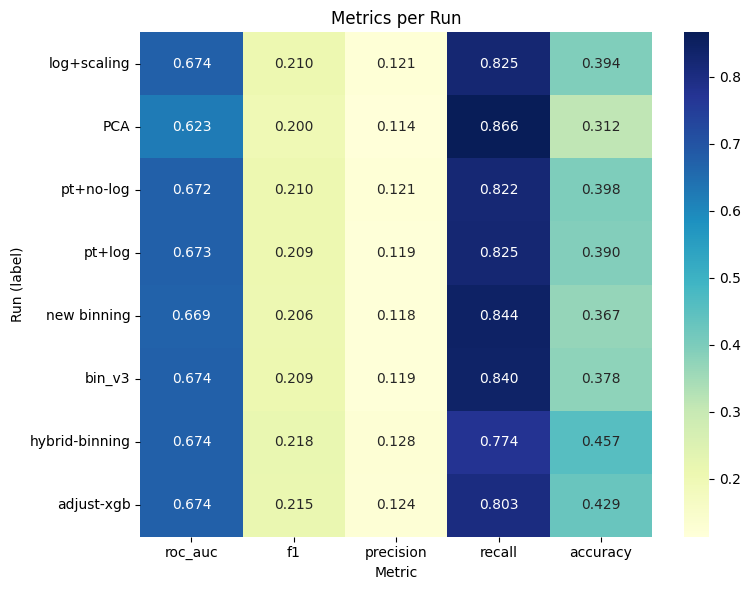

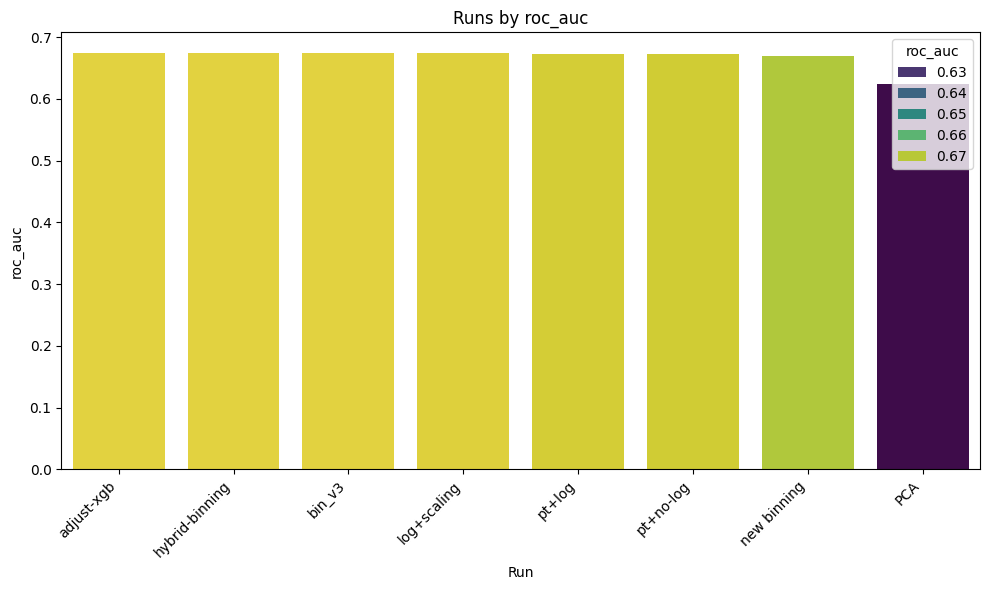

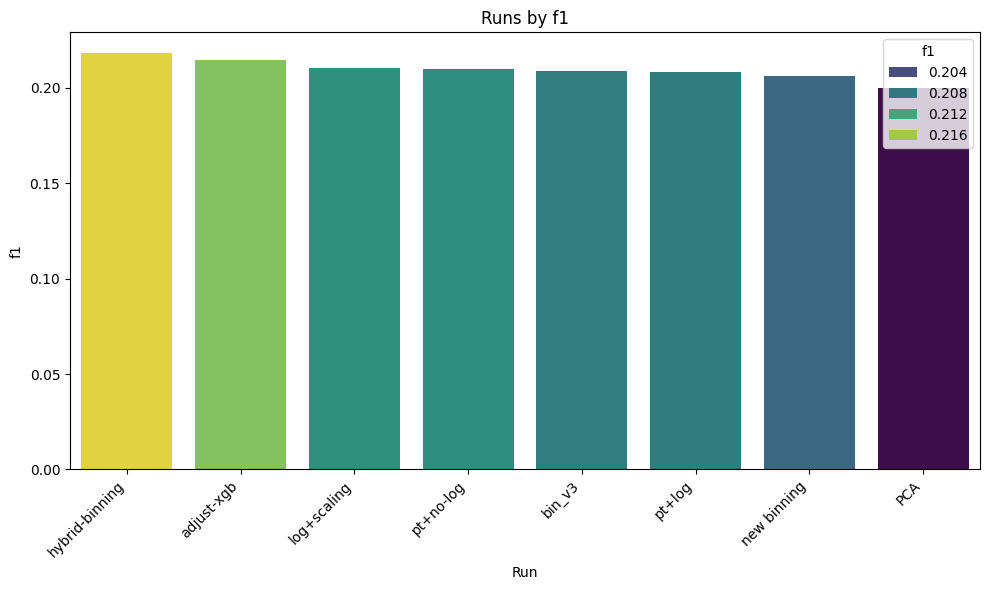

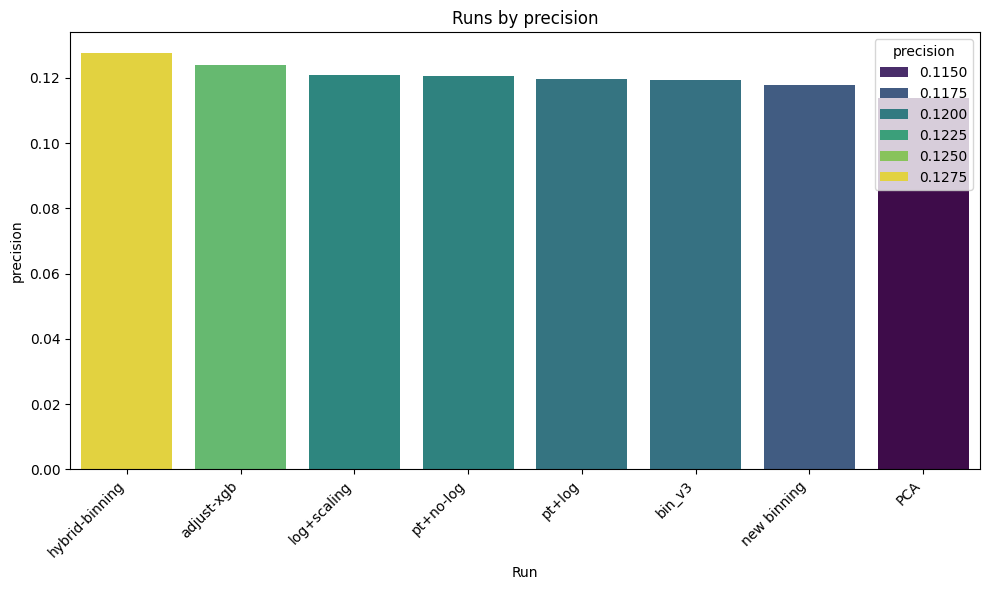

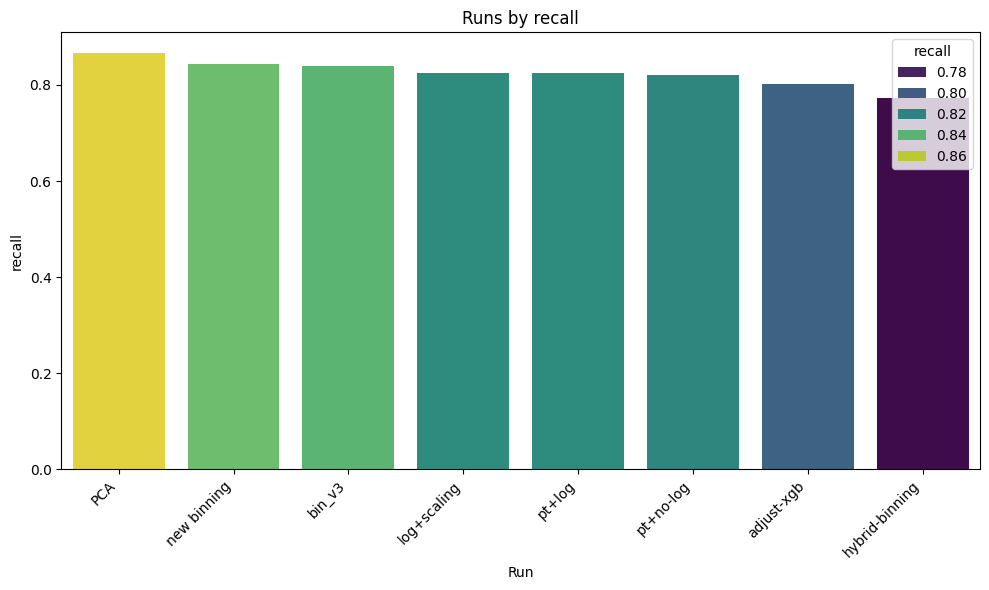

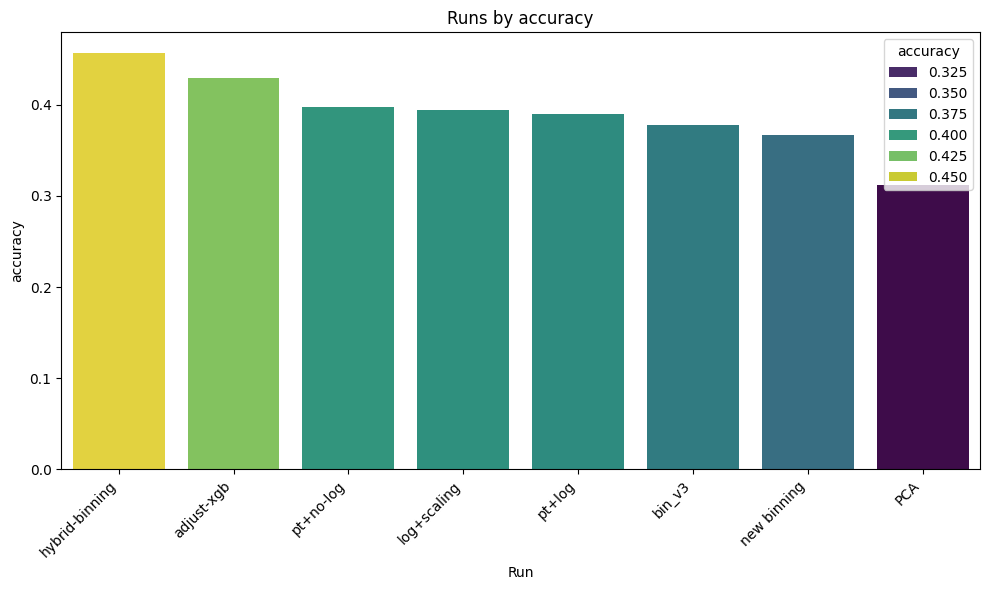

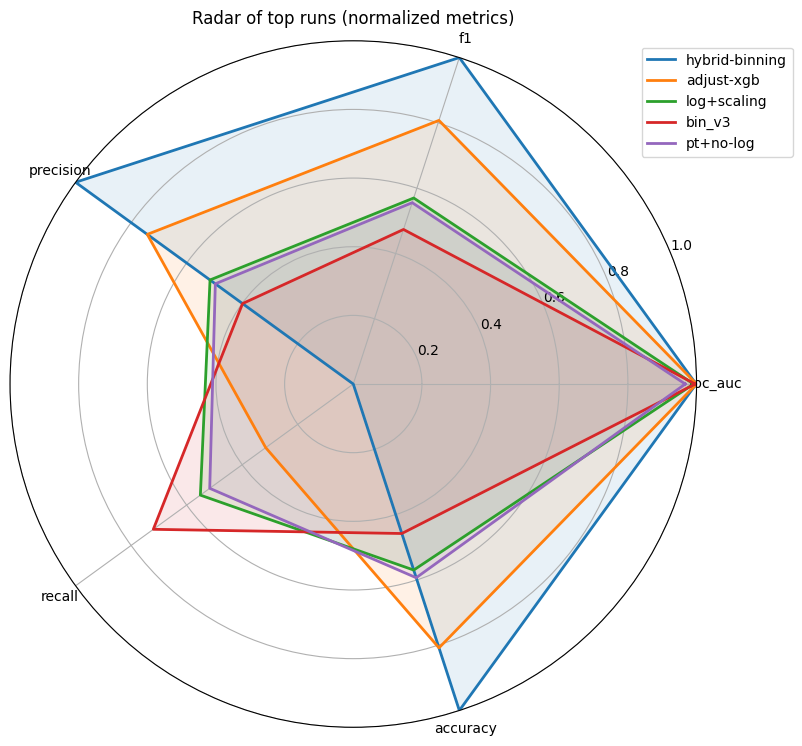

,run_id,label,roc_auc,f1,precision,recall,accuracy,rank_roc_auc,rank_f1,rank_precision,rank_recall,rank_accuracy,rank_sum,overall_score
0,8,hybrid-binning,0.674071,0.218267,0.127536,0.773892,0.456690,2.0,1.0,1.0,8.0,1.0,13.0,0.771429
1,9,adjust-xgb,0.674132,0.214753,0.123960,0.802997,0.428921,1.0,2.0,2.0,7.0,2.0,14.0,0.742857
2,1,log+scaling,0.673702,0.210414,0.120832,0.824718,0.394438,4.0,3.0,3.0,4.0,4.0,18.0,0.628571
3,6,bin_v3,0.673936,0.208656,0.119211,0.840356,0.378241,3.0,5.0,6.0,3.0,6.0,23.0,0.485714
4,3,pt+no-log,0.672461,0.210153,0.120568,0.821604,0.397838,6.0,4.0,4.0,6.0,3.0,23.0,0.485714
5,4,pt+log,0.672828,0.208591,0.119499,0.824500,0.390067,5.0,6.0,5.0,5.0,5.0,26.0,0.400000
6,5,new binning,0.669266,0.206300,0.117626,0.843831,0.367092,7.0,7.0,7.0,2.0,7.0,30.0,0.285714
7,2,PCA,0.623478,0.200012,0.113691,0.866203,0.311991,8.0,8.0,8.0,1.0,8.0,33.0,0.200000


In [20]:
from shared_util.metrics.compare_linear import compare_runs

compare_runs(
    df=df_label,
    metric_cols=["roc_auc", "f1", "precision", "recall", "accuracy"]
)

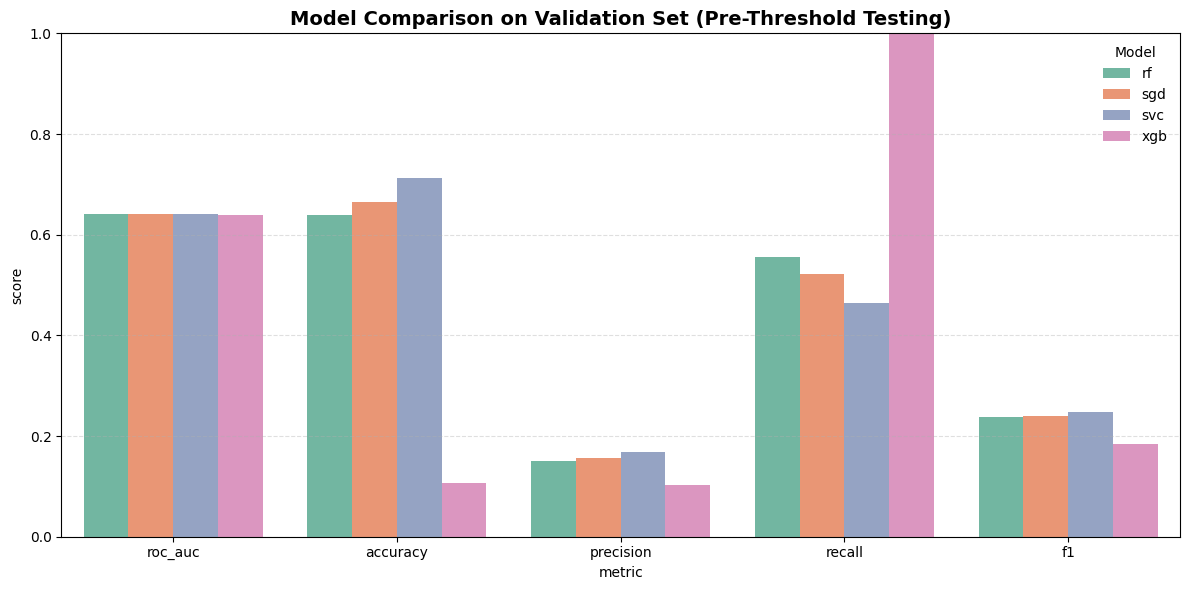

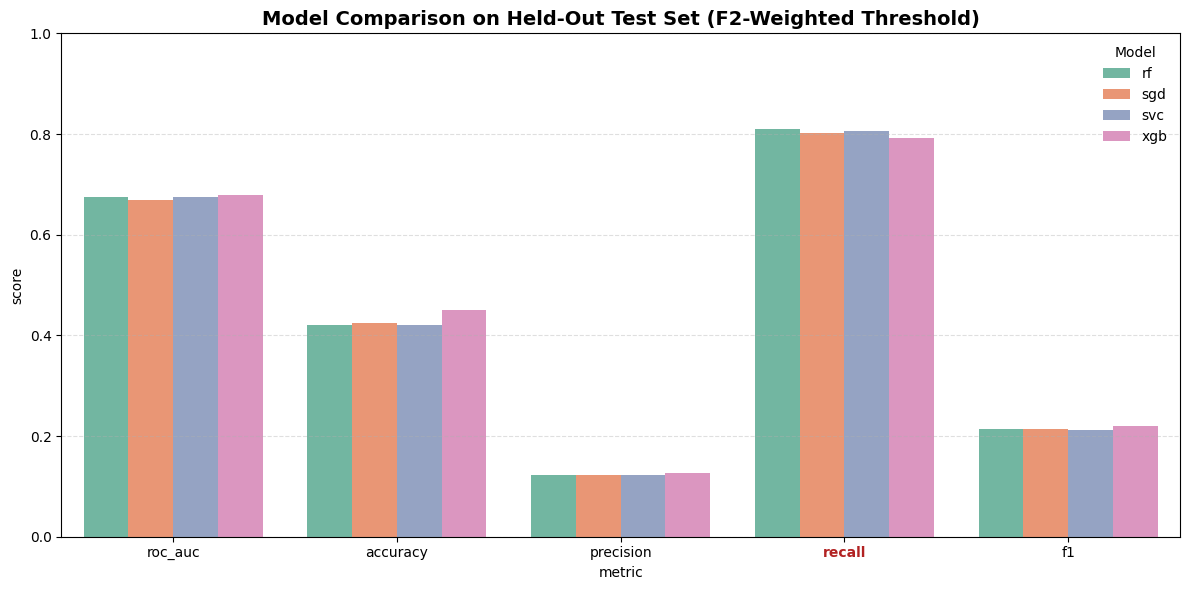

In [21]:
from shared_util.results.results import summary_by_auc, summary_by_recall, plot_metrics

plot_metrics(most_recent_df, METRICS_DB_ID)

In [5]:
print('--most recent--')
summary_by_auc(most_recent_df, plot_id=METRICS_DB_ID)
summary_by_recall(most_recent_df)

# print('--no pca--')
# summary_by_auc(results_df, plot_id=1)
# summary_by_recall(results_df)



--most recent--
Models by ROC_AUC


,model,roc_auc
0,xgb,0.681
1,rf,0.676
2,svc,0.670
3,sgd,0.669


Models by Recall


,model,recall
7,sgd,0.891
4,svc,0.836
0,xgb,0.820
11,rf,0.814


### Hyperparameter Display

In [ ]:
from shared_util.fetch import fetch_params_by_id
import pandas as pd
import ast
import re

h_params_df = fetch_params_by_id(run_id=METRICS_DB_ID)

h_params_df.head(5)


_np_wrapper = re.compile(r"np\.(?:float|int)\d+\(([^)]+)\)")

def parse_hyperparams(text: str) -> pd.DataFrame:
    cleaned = _np_wrapper.sub(r"\1", text)
    params = ast.literal_eval(cleaned)

    def normalize(value):
        if isinstance(value, np.generic):
            return value.item()
        return value

    data = {k: normalize(v) for k, v in params.items()}
    return pd.DataFrame(data.items(), columns=["param", "value"])

for row in h_params_df.itertuples():
    print(f'Model: {row.model}')
    display(parse_hyperparams(row.hyperparam_text)) # type: ignore


Model: xgb


,param,value
0,model__colsample_bytree,5.325258e-01
1,model__gamma,4.744428e+00
2,model__learning_rate,2.900333e-01
3,model__max_depth,3.000000e+00
4,model__min_child_weight,9.000000e+00
5,model__n_estimators,7.640000e+02
6,model__reg_alpha,4.132918e-07
7,model__reg_lambda,5.285382e-02
8,model__scale_pos_weight,1.614304e+01
9,model__subsample,8.049983e-01


Model: svc


,param,value
0,model__C,4.418442
1,model__class_weight,balanced
2,model__gamma,0.001
3,model__kernel,rbf
4,model__shrinking,False


Model: sgd


,param,value
0,model__tol,0.001
1,model__shuffle,True
2,model__penalty,l2
3,model__max_iter,100
4,model__loss,hinge
5,model__learning_rate,adaptive
6,model__l1_ratio,0.5
7,model__eta0,0.0003
8,model__class_weight,None
9,model__average,True


# Random Forest

After reading (Liu, V. et al.) and (Mahmoud, M. et al.) I decided to begin expirementing with random forest models instead of logistic regression models.

In other studies, random forest models were shown to out perform logsitic regression and support vector models likely due to the mix of tabular, categorical, and numerical features

### Define Pipeline

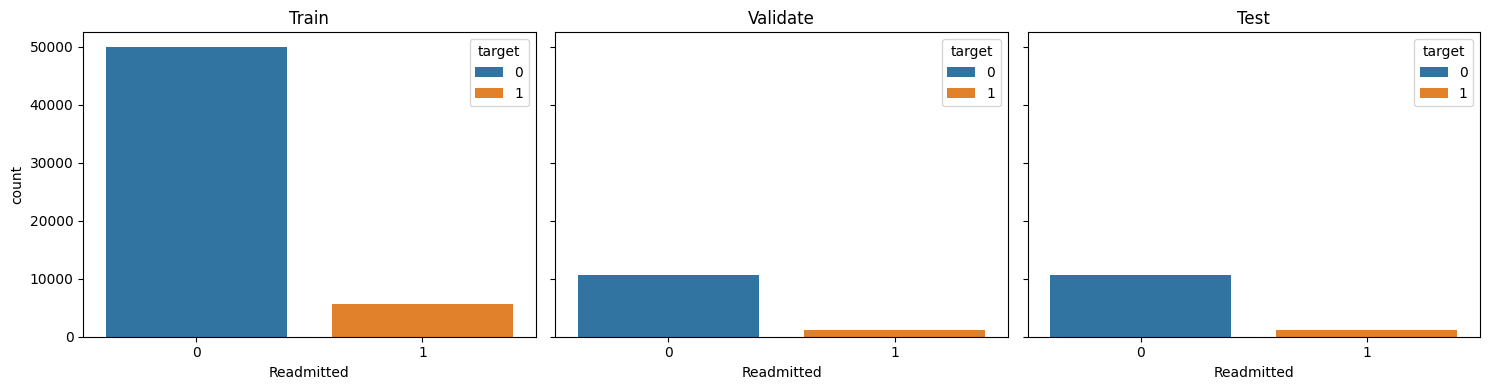

In [3]:

model = 'rf' # Random Forest


model_pipe = ModelPipeline(
    log=UPDATE_DATABASE,
    metrics_db_id=METRICS_DB_ID,
    metrics_notes=METRICS_NOTES,        
    data_path='cleaned',             # csv file name where the data is
    plot_y_dist=True,                # show the target distribution between splits   
    random_state=42,
    log_transform_cols=np.array([]), # no need to transform for tree models
    model=model,
    scaler=None,
    group_by_col='patient_nbr',
    create_interactions=False, # no interaction terms for tree models
    one_hot_ordinal=False, # no one-hot encoding for tree models, use int based grouping
)

### Baseline

Get a baseline before looking at feature importance or hyperparameter tuning

We can use this baseline to check class imbalance approach methods, as well as to get a sense if this model can learn anything from the engineered features

In [4]:
model_pipe.run_baseline(
    run_smote=True,
    run_undersampler=True,
    show_duration_info=True,
)

--------SMOTE Baseline--------
roc_auc score per fold:  [0.59  0.599 0.594 0.602 0.586]
mean roc_auc score: , 0.594
connected to database
-----Undersample Baseline-----
roc_auc score per fold:  [0.641 0.634 0.623 0.652 0.627]
mean roc_auc score: , 0.635
Duration: 0 hrs, 0 mins, 20.6 secs


After several iterations of data cleaning tweaks, baseline SMOTE is performing significantly better with mean ROC of ~0.59

However the random under sampler still outperforms with a mean AUC_ROC of ~0.63

SMOTE performed worse than under sampling so we will stick with under sampling going forward

A mean ROC_AUC score of 0.630 implies that the model has learned something from the data so we will continue analysis.

### Feature Importance

- Tree impurity based importance is naturaly skewed to favor continuous features
- Permutation importance is model agnostic, is uneffected by the large class imbalance, and is not effected by the under sampling technique used

,feature,importance_mean,importance_std
4,number_inpatient,0.069337,0.007399
5,number_diagnoses,0.003936,0.001551
3,num_medications,0.002776,0.004569
1,num_lab_procedures,0.002603,0.000981
13,diag1_group_respiratory,0.002541,0.001461
0,time_in_hospital,0.002358,0.001697
35,specialty_cat_cardiology,0.002161,0.000345
59,v_emergency_group_several,0.001551,0.000569
49,admit_type_group_elective,0.001487,0.001395
56,v_emergency_group_few,0.001238,0.001340


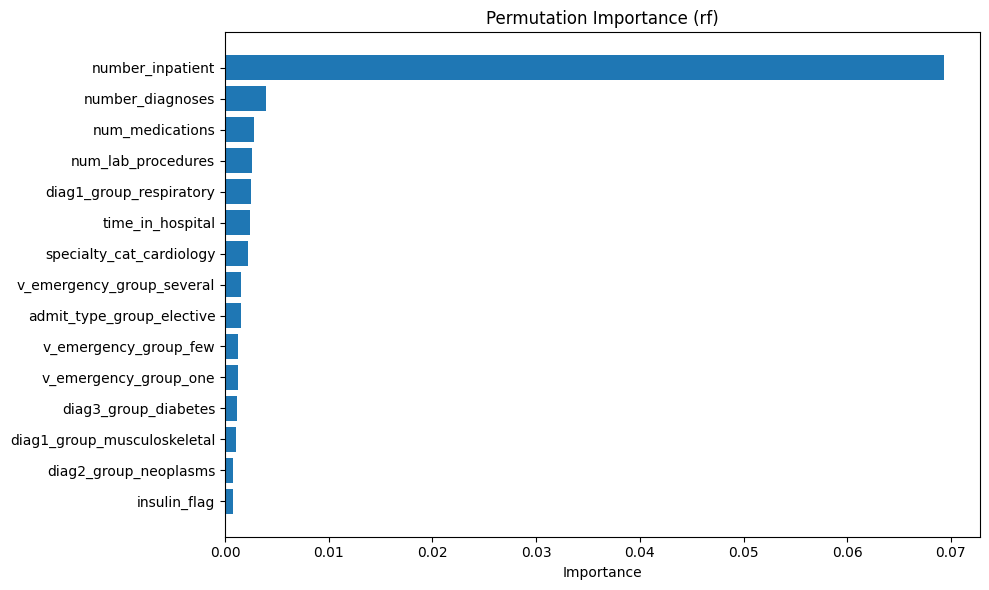

Duration: 0 hrs, 0 mins, 49.6 secs


In [5]:
model_pipe.permute_importance(
    print_num=15,
    plot=True,
    show_duration_info=True
)

In [6]:
param_grid = {
        'model__n_estimators': [100, 200, 500],
        'model__max_depth': [None, 10, 20, 30],
        'model__min_samples_split': [2, 5, 10, 15, 20],
        'model__min_samples_leaf': [1, 2, 4, 6, 10],
        'model__max_features': ['sqrt', 'log2', 0.2, 0.5],
        'model__class_weight': [None, 'balanced'],
        'model__bootstrap': [True, False],
        'model__oob_score': [True, False]
    }

model_pipe.run_hyperparam_search(
    hyperparam_dist=param_grid,
    param_scoring='roc_auc',
    n_iter=30,
    n_jobs=-1,
    refit=True,
    show_duration_info=True
)

Fitting 5 folds for each of 30 candidates, totalling 150 fits
Best ROC_AUC (cv): 0.6580816702000197
Best params: {'model__oob_score': True, 'model__n_estimators': 200, 'model__min_samples_split': 15, 'model__min_samples_leaf': 6, 'model__max_features': 'log2', 'model__max_depth': 10, 'model__class_weight': None, 'model__bootstrap': True}
logged hyperparameters
Duration: 0 hrs, 0 mins, 34.8 secs


In [7]:
model_pipe.validate(
    show_duration_info=False,
    use_local_model=False
)

# model_pipe.validate(
#     show_duration_info=True,
#     use_local_model=True,
#     oob_score=True,
#     n_estimators=200,
#     min_samples_split=10,
#     min_samples_leaf=4,
#     max_features=0.2,
#     max_depth=10,
#     class_weight='balanced',
#     bootstrap=True
# )

Held out validation metrics: rf
ROC_AUC:     0.6412181503164449
Accuracy:      0.6385410538700731
F1 score:      0.2378167641325536
Precision:     0.1512965050732807
Recall:        0.5554635761589404

Confusion matrix:

TN: 6927, FP: 3764, FN: 537, TP: 671

Classification report:
               precision    recall  f1-score   support

           0       0.93      0.65      0.76     10691
           1       0.15      0.56      0.24      1208

    accuracy                           0.64     11899
   macro avg       0.54      0.60      0.50     11899
weighted avg       0.85      0.64      0.71     11899



Best threshold (F2): 0.4441
Precision: 0.123  Recall: 0.791  F2: 0.380


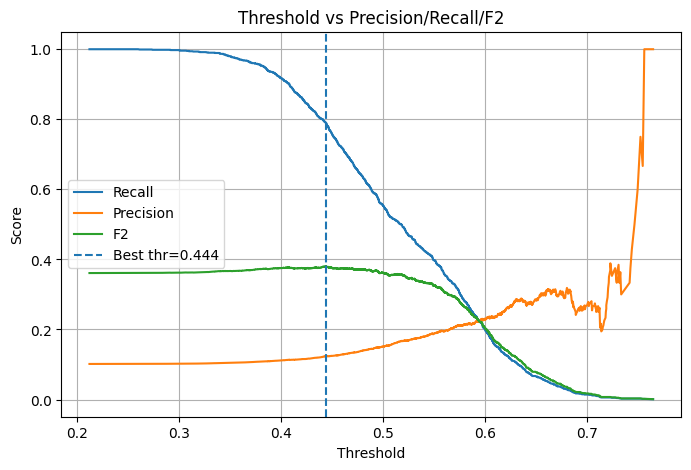

ROC_AUC:     0.6746510779483605
Accuracy:      0.42047470225525807
F1 score:      0.2138191818494328
Precision:     0.1231520591341077
Recall:        0.8105994787141616

Confusion matrix:

TN: 4045, FP: 6643, FN: 218, TP: 933

Classification report:
               precision    recall  f1-score   support

           0       0.95      0.38      0.54     10688
           1       0.12      0.81      0.21      1151

    accuracy                           0.42     11839
   macro avg       0.54      0.59      0.38     11839
weighted avg       0.87      0.42      0.51     11839



In [8]:
model_pipe.test(
    use_f2_threshold=True,
    show_duration_info=False,
    show_plot=True,
    use_local_model=False
)
# model_pipe.test(
#     use_f2_threshold=True,
#     show_duration_info=True,
#     show_plot=True,
#     use_local_model=True,
#     oob_score=True,
#     n_estimators=200,
#     min_samples_split=10,
#     min_samples_leaf=4,
#     max_features=0.2,
#     max_depth=10,
#     class_weight='balanced',
#     bootstrap=True
# )

# Stochastic Gradient Descent Classifier

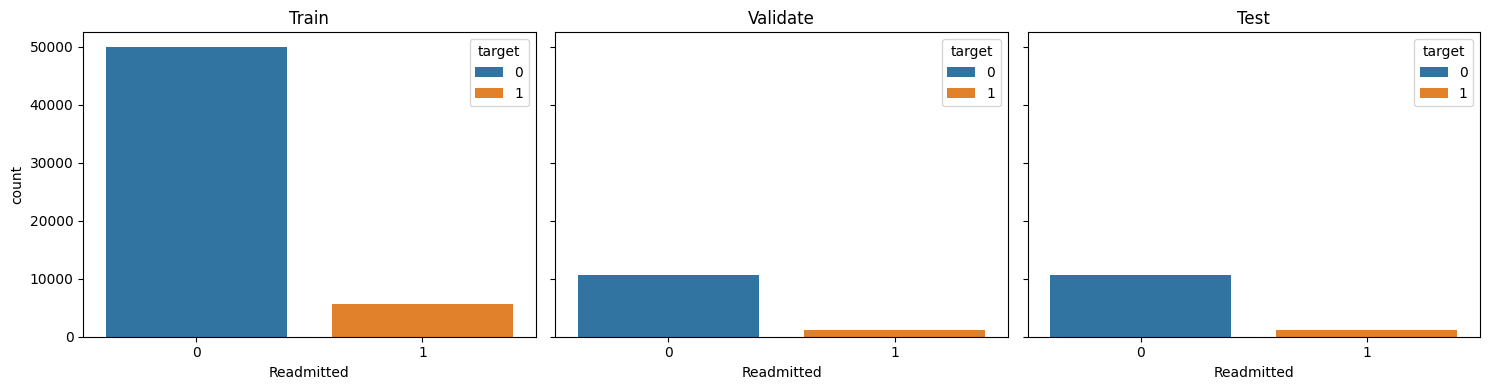

In [9]:
model = 'sgd' #SGDClassifier


sgd_pipe = ModelPipeline(
    log=UPDATE_DATABASE,
    metrics_db_id=METRICS_DB_ID,
    metrics_notes=METRICS_NOTES,
    log_transform_cols=LOG_TRANSFORM_COLS,
    model=model,
    scaler=scaler,
    use_pca=PCA,
    create_interactions=True,
    one_hot_ordinal=True
)



,feature,importance_mean,importance_std
4,number_inpatient,0.054963,0.006890
5,number_diagnoses,0.005669,0.003299
0,time_in_hospital,0.005173,0.004857
10,diag1_group_musculoskeletal,0.004845,0.001632
19,diag2_group_neoplasms,0.003122,0.001824
58,v_emergency_group_one,0.002674,0.001544
64,num_drugs,0.002634,0.000435
13,diag1_group_respiratory,0.002579,0.001355
56,v_emergency_group_few,0.002406,0.001642
3,num_medications,0.002375,0.002623


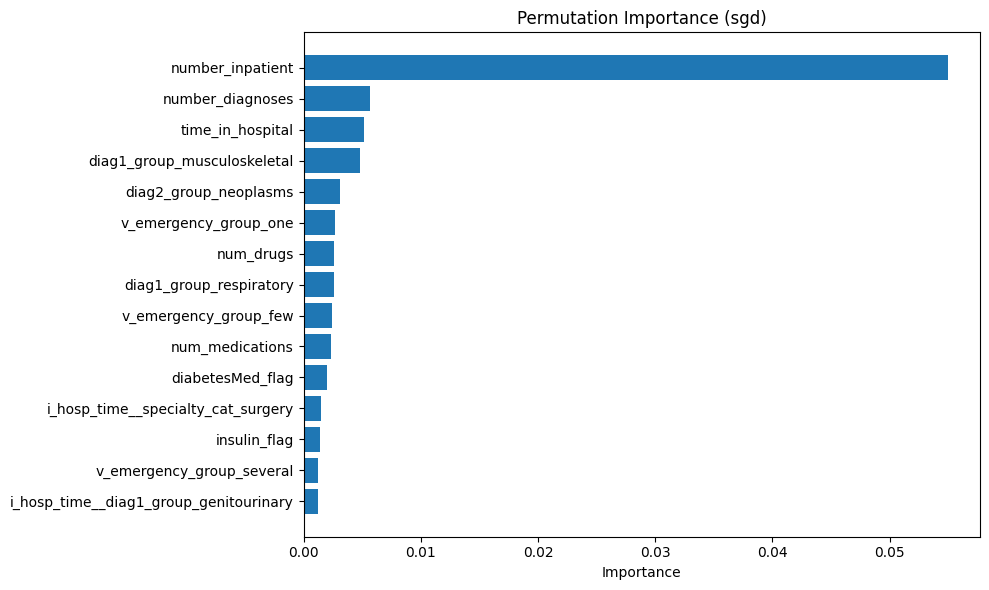

Duration: 0 hrs, 0 mins, 15.5 secs


In [10]:
if not PCA:
    sgd_pipe.permute_importance()

In [11]:
sgd_pipe.run_baseline() # all true

--------SMOTE Baseline--------
roc_auc score per fold:  [0.571 0.565 0.553 0.545 0.551]
mean roc_auc score: , 0.557
-----Undersample Baseline-----
roc_auc score per fold:  [0.596 0.597 0.617 0.603 0.619]
mean roc_auc score: , 0.606
Duration: 0 hrs, 0 mins, 12.5 secs


In [12]:
sgd_param_grid = {
    "model__loss": ["log_loss", "modified_huber", "hinge", "squared_hinge"],
    "model__penalty": ["l2", "l1", "elasticnet"],
    "model__alpha": [1e-6, 1e-5, 1e-4, 1e-3, 1e-2],
    "model__l1_ratio": [0.1, 0.5, 0.9],
    "model__learning_rate": ["constant", "optimal", "invscaling", "adaptive"],
    "model__eta0": [1e-4, 3e-4, 1e-3, 3e-3, 1e-2, 3e-2, 1e-1],
    "model__max_iter": [100, 500, 1000],
    "model__tol": [1e-3, 1e-4],
    "model__class_weight": [None, "balanced"],
    "model__average": [False, True, 5, 10],
    "model__shuffle": [True],
}

sgd_pipe.run_hyperparam_search(hyperparam_dist=sgd_param_grid)

Fitting 5 folds for each of 30 candidates, totalling 150 fits
Best ROC_AUC (cv): 0.6581712438338926
Best params: {'model__tol': 0.0001, 'model__shuffle': True, 'model__penalty': 'l1', 'model__max_iter': 500, 'model__loss': 'modified_huber', 'model__learning_rate': 'invscaling', 'model__l1_ratio': 0.9, 'model__eta0': 0.003, 'model__class_weight': None, 'model__average': 10, 'model__alpha': 0.001}
logged hyperparameters
Duration: 0 hrs, 0 mins, 43.9 secs


In [13]:
sgd_pipe.validate(show_duration_info=False)

Held out validation metrics: sgd
ROC_AUC:     0.6419034144582836
Accuracy:      0.6640053786032439
F1 score:      0.23992395437262357
Precision:     0.15572556762092793
Recall:        0.5223509933774835

Confusion matrix:

TN: 7270, FP: 3421, FN: 577, TP: 631

Classification report:
               precision    recall  f1-score   support

           0       0.93      0.68      0.78     10691
           1       0.16      0.52      0.24      1208

    accuracy                           0.66     11899
   macro avg       0.54      0.60      0.51     11899
weighted avg       0.85      0.66      0.73     11899



Best threshold (F2): 0.4120
Precision: 0.124  Recall: 0.798  F2: 0.383


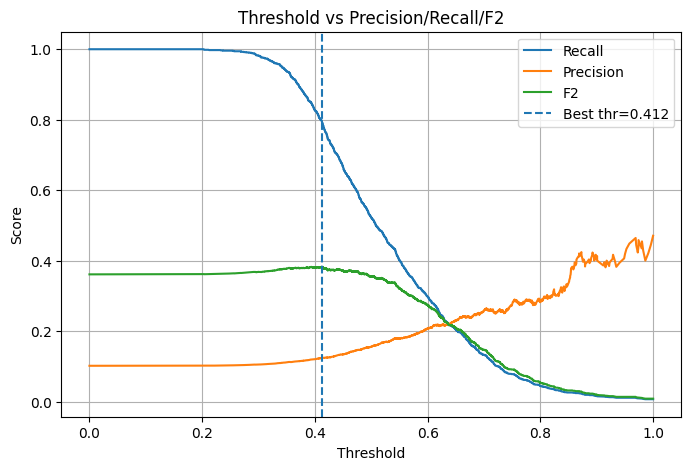

ROC_AUC:     0.6694076551501689
Accuracy:      0.42385336599374945
F1 score:      0.2131733763986619
Precision:     0.12290502793296089
Recall:        0.8027801911381407

Confusion matrix:

TN: 4094, FP: 6594, FN: 227, TP: 924

Classification report:
               precision    recall  f1-score   support

           0       0.95      0.38      0.55     10688
           1       0.12      0.80      0.21      1151

    accuracy                           0.42     11839
   macro avg       0.54      0.59      0.38     11839
weighted avg       0.87      0.42      0.51     11839



In [14]:
sgd_pipe.test(show_duration_info=False)

# Support Vector Classifier

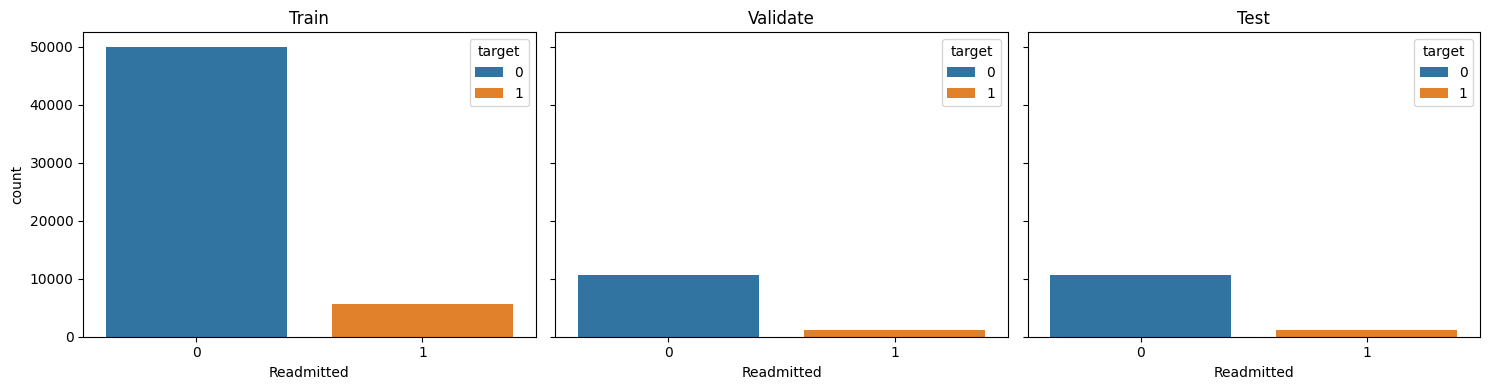

In [15]:

svc_pipe = ModelPipeline(
    model='svc',
    log=UPDATE_DATABASE,
    metrics_db_id=METRICS_DB_ID,
    metrics_notes=METRICS_NOTES,
    log_transform_cols=LOG_TRANSFORM_COLS,
    scaler=scaler,
    use_pca=PCA,
    create_interactions=True,
    one_hot_ordinal=True
)

In [16]:
svc_pipe.run_baseline(run_smote=False) # smote did not complete after ~6 hours

-----Undersample Baseline-----
roc_auc score per fold:  [0.643 0.635 0.641 0.66  0.638]
mean roc_auc score: , 0.643
Duration: 0 hrs, 0 mins, 17.6 secs


In [17]:
# slow
# svc_pipe.permute_importance()

In [18]:
from scipy.stats import loguniform


# limited param search due to computation time
svc_param_grid = {
    "model__C": loguniform(1e-3, 1e3),
    "model__gamma": [0.0001, 0.001, 0.01, 0.1, 1],     
}

svc_pipe.run_hyperparam_search(hyperparam_dist=svc_param_grid)

Fitting 5 folds for each of 30 candidates, totalling 150 fits
Best ROC_AUC (cv): 0.6581494263329176
Best params: {'model__C': np.float64(2.3973382079286494), 'model__gamma': 0.001}
logged hyperparameters
Duration: 0 hrs, 11 mins, 6.0 secs


In [19]:
# Best params: {'model__C': np.float64(4.418441521199722), 'model__gamma': 0.001}
svc_pipe.validate()

Held out validation metrics: svc
ROC_AUC:     0.6411854744443708
Accuracy:      0.7122447264476006
F1 score:      0.24714160070360597
Precision:     0.16826347305389222
Recall:        0.4652317880794702

Confusion matrix:

TN: 7913, FP: 2778, FN: 646, TP: 562

Classification report:
               precision    recall  f1-score   support

           0       0.92      0.74      0.82     10691
           1       0.17      0.47      0.25      1208

    accuracy                           0.71     11899
   macro avg       0.55      0.60      0.53     11899
weighted avg       0.85      0.71      0.76     11899



Best threshold (F2): -0.7312
Precision: 0.124  Recall: 0.798  F2: 0.383


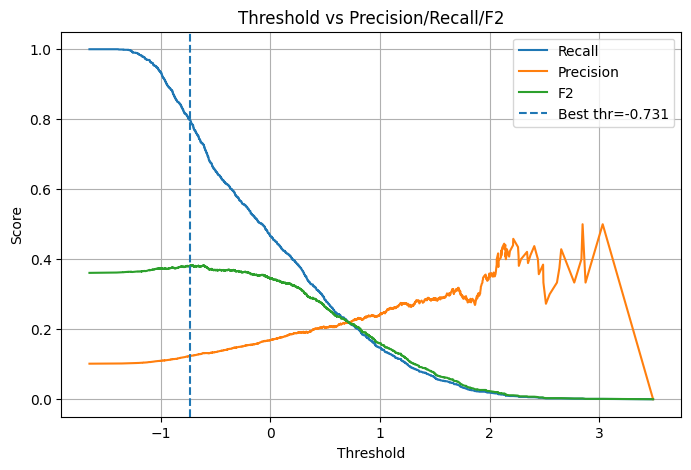

ROC_AUC:     0.6741491224761598
Accuracy:      0.4203902356617958
F1 score:      0.21289286533608626
Precision:     0.12263776926126603
Recall:        0.8062554300608167

Confusion matrix:

TN: 4049, FP: 6639, FN: 223, TP: 928

Classification report:
               precision    recall  f1-score   support

           0       0.95      0.38      0.54     10688
           1       0.12      0.81      0.21      1151

    accuracy                           0.42     11839
   macro avg       0.54      0.59      0.38     11839
weighted avg       0.87      0.42      0.51     11839



In [20]:
svc_pipe.test()

# XGBoost

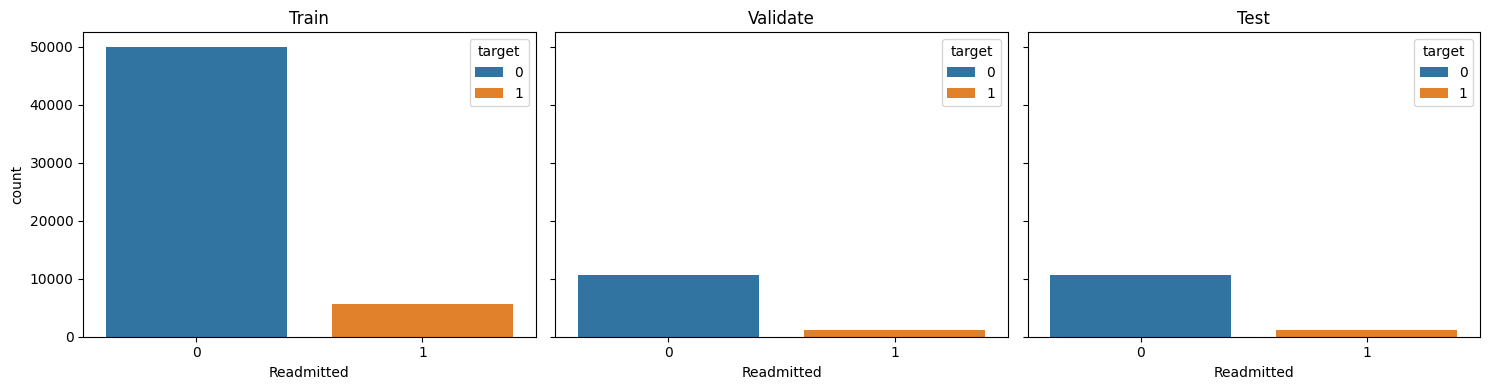

In [9]:
xgb_pipe = ModelPipeline(
    model='xgb',
    metrics_db_id=METRICS_DB_ID,
    metrics_notes=METRICS_NOTES,
    log=UPDATE_DATABASE,
    create_interactions=False,
    log_transform_cols=np.array([]),
    use_pca=PCA,
    scaler=None,
    one_hot_ordinal=False,
    resample=False # handled by hyperparameters
)

In [11]:
xgb_pipe.run_baseline()

--------SMOTE Baseline--------
roc_auc score per fold:  [0.63  0.63  0.634 0.642 0.629]
mean roc_auc score: , 0.633
-----Undersample Baseline-----
roc_auc score per fold:  [0.63  0.63  0.634 0.642 0.629]
mean roc_auc score: , 0.633
Duration: 0 hrs, 0 mins, 12.7 secs


In [ ]:
if not PCA:
    xgb_pipe.permute_importance()

In [12]:
from scipy.stats import randint, uniform, loguniform

# approx_spw = float(8.9494) # from data exploration aprox inverse of class balance


param_dist = {
    'model__max_depth': [3,4,5],
    'model__min_child_weight': [1,2,4],
    'model__subsample': [0.6,0.8,1.0],
    'model__colsample_bytree': [0.6,0.8,1.0],
    'model__gamma': [0,1,3],
    'model__learning_rate': [0.02, 0.05, 0.1],
    'model__scale_pos_weight': [1,2,4,6,8,10]
}

xgb_pipe.run_hyperparam_search(
    hyperparam_dist=param_dist
)

Fitting 5 folds for each of 30 candidates, totalling 150 fits
Best ROC_AUC (cv): 0.6623979593997842
Best params: {'model__subsample': 0.6, 'model__scale_pos_weight': 4, 'model__min_child_weight': 2, 'model__max_depth': 3, 'model__learning_rate': 0.1, 'model__gamma': 0, 'model__colsample_bytree': 0.8}
Duration: 0 hrs, 0 mins, 35.1 secs


In [13]:
xgb_pipe.validate()

Held out validation metrics: xgb
ROC_AUC:     0.6437720174981617
Accuracy:      0.8701571560635347
F1 score:      0.1889763779527559
Precision:     0.2582496413199426
Recall:        0.1490066225165563

Confusion matrix:

TN: 10174, FP: 517, FN: 1028, TP: 180

Classification report:
               precision    recall  f1-score   support

           0       0.91      0.95      0.93     10691
           1       0.26      0.15      0.19      1208

    accuracy                           0.87     11899
   macro avg       0.58      0.55      0.56     11899
weighted avg       0.84      0.87      0.85     11899



Best threshold (F2): 0.2283
Precision: 0.122  Recall: 0.808  F2: 0.381


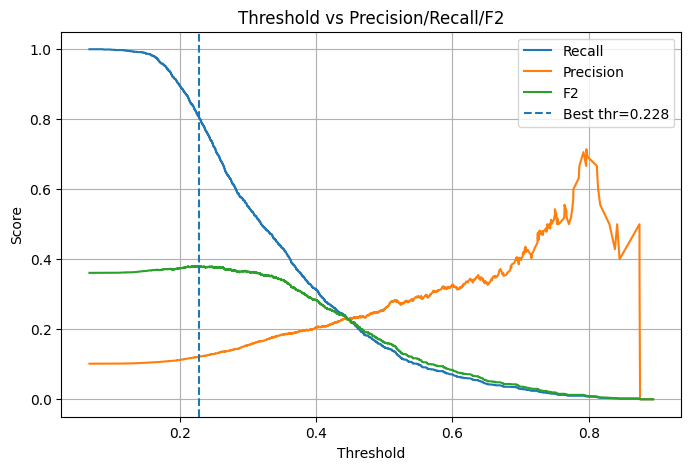

ROC_AUC:     0.6760256637030024
Accuracy:      0.3986823211419883
F1 score:      0.21084137013634852
Precision:     0.12083862770012707
Recall:        0.8262380538662033

Confusion matrix:

TN: 3769, FP: 6919, FN: 200, TP: 951

Classification report:
               precision    recall  f1-score   support

           0       0.95      0.35      0.51     10688
           1       0.12      0.83      0.21      1151

    accuracy                           0.40     11839
   macro avg       0.54      0.59      0.36     11839
weighted avg       0.87      0.40      0.48     11839



In [14]:
xgb_pipe.test()

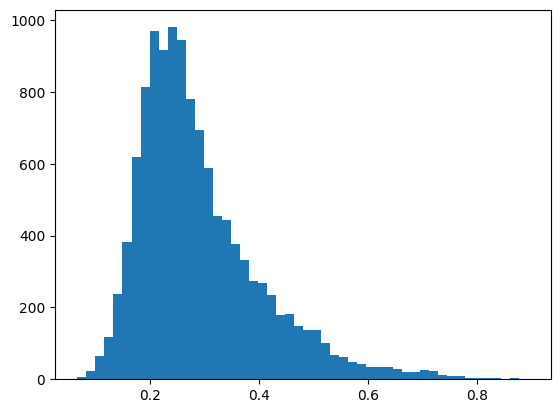

In [15]:
import matplotlib.pyplot as plt
from shared_util.dataio import load_csv



df = load_csv('cleaned')
from shared_util.split import group_split

X_train, X_validate, X_test, y_train, y_validate, y_test = group_split(df)
plt.hist(xgb_pipe.randomized_search.best_estimator_.predict_proba(X_validate)[:,1], bins=50) #type: ignore
plt.show()
